# Map Quality Classifier — Training Notebook

Trains a **Random Forest** and an **XGBoost** binary classifier to predict
whether a drone-map stitching result is acceptable (`pass`) or not (`fail`).

**Inputs:** `features.csv` produced by `extract_features.py`  
**Outputs:** versioned model in `models/v{N}/` + `models/latest/` symlink

Run all cells top-to-bottom for a fresh training run.  
To retrain on new data: update `FEATURE_CSVS` in the config cell, re-run.


In [4]:
import warnings; warnings.filterwarnings("ignore")

import json, joblib
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV,
)
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay,
)
from sklearn.calibration import CalibrationDisplay
from xgboost import XGBClassifier

try:
    import shap; _SHAP = True
except ImportError:
    _SHAP = False
    print("[warn] shap not installed — pip install shap to enable SHAP analysis")

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline


## 0 · Configuration
Edit this cell before running anything else.

In [5]:
# ── Inputs ────────────────────────────────────────────────────────────────────
FEATURE_CSVS     = [Path("18-21/features.csv")]   # add more paths for future sweeps

# ── Output ────────────────────────────────────────────────────────────────────
MODEL_DIR        = Path("models")

# ── Training ──────────────────────────────────────────────────────────────────
RANDOM_STATE     = 42
TEST_SIZE        = 0.20       # fraction held out for final evaluation
CV_FOLDS         = 5          # StratifiedKFold splits
RS_ITER_RF       = 50         # RandomizedSearch iterations — Random Forest
RS_ITER_XGB      = 60         # RandomizedSearch iterations — XGBoost
N_JOBS           = -1         # -1 = all CPU cores

# ── Inference operating point ─────────────────────────────────────────────────
# Predict "pass" only when P(pass) >= chosen_threshold.
# The threshold is selected so precision on "pass" >= TARGET_PRECISION.
# Raise this if false positives (accepting a bad map) are causing problems.
TARGET_PRECISION = 0.90


## 1 · Load & Inspect Data

In [6]:
dfs = []
for p in FEATURE_CSVS:
    df = pd.read_csv(p)
    df["_source"] = p.stem
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)

# Deduplicate on (sweep, run_id) — keep last occurrence so newer sweeps win
raw = raw.drop_duplicates(subset=["sweep", "run_id"], keep="last").reset_index(drop=True)

print(f"Rows: {len(raw)}  |  Columns: {len(raw.columns)}")
print(f"Sources: {[p.name for p in FEATURE_CSVS]}\n")

vc = raw["label"].value_counts()
print("Label distribution:")
for lbl, n in vc.items():
    print(f"  {lbl:12s}  {n:4d}  ({100*n/len(raw):.1f}%)")


Rows: 670  |  Columns: 87
Sources: ['features.csv']

Label distribution:
  pass           535  (79.9%)
  fail           135  (20.1%)


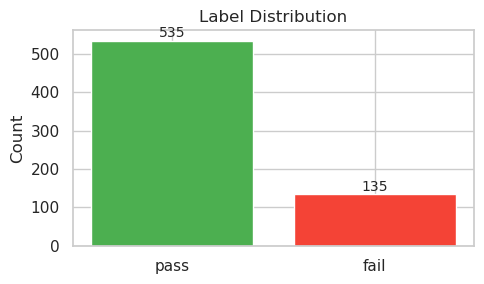

In [7]:
# Visual class distribution
fig, ax = plt.subplots(figsize=(5, 3))
colors = {"pass": "#4caf50", "fail": "#f44336", "unsure": "#ff9800", "unlabeled": "#9e9e9e"}
labels_order = [l for l in ["pass", "fail", "unsure", "unlabeled"] if l in vc.index]
counts = [vc.get(l, 0) for l in labels_order]
bars = ax.bar(labels_order, counts, color=[colors[l] for l in labels_order], edgecolor="white")
for bar, n in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(n),
            ha="center", va="bottom", fontsize=10)
ax.set_title("Label Distribution")
ax.set_ylabel("Count")
plt.tight_layout(); plt.show()


In [8]:
# Group 6 coverage (stitcher stats — populated when server has diagnostics_path)
G6 = [c for c in raw.columns if c.startswith(("stitcher_", "pg_"))]
if G6:
    cov = (raw[G6] != -1.0).any(axis=1).mean()
    print(f"Group 6 coverage (stitcher stats / pose-graph): {cov:.1%} of rows")
    if cov < 0.5:
        print("  → Low. These features will have limited signal until the server")
        print("    is updated to write stitcher_diagnostics.json.")
    print()

# Missing value summary (sentinel = -1.0)
diag_cols = [c for c in raw.columns if any(c.startswith(p)
    for p in ("stitch_","dewarp_","green_","blob_","marker_","stitcher_","pg_"))]
missing_frac = (raw[diag_cols] == -1.0).mean().sort_values(ascending=False)
top_missing = missing_frac[missing_frac > 0.05]
if not top_missing.empty:
    print("Features with >5% sentinel (-1.0) values:")
    for feat, frac in top_missing.items():
        print(f"  {feat:45s}  {frac:.1%}")
else:
    print("No features with >5% missing values.")


Group 6 coverage (stitcher stats / pose-graph): 100.0% of rows

Features with >5% sentinel (-1.0) values:
  blob_min_consistency                           100.0%
  blob_count_high_consistency                    100.0%
  pg_frame_count                                 100.0%
  pg_edge_count                                  100.0%
  pg_marker_count                                100.0%
  pg_rms_ratio                                   100.0%
  pg_rms_after                                   100.0%
  pg_rms_before                                  100.0%
  blob_mean_consistency                          100.0%
  blob_std_consistency                           100.0%
  marker_goal_inside_hull                        10.6%
  marker_goal_x_norm                             10.6%
  marker_goal_y_norm                             10.6%


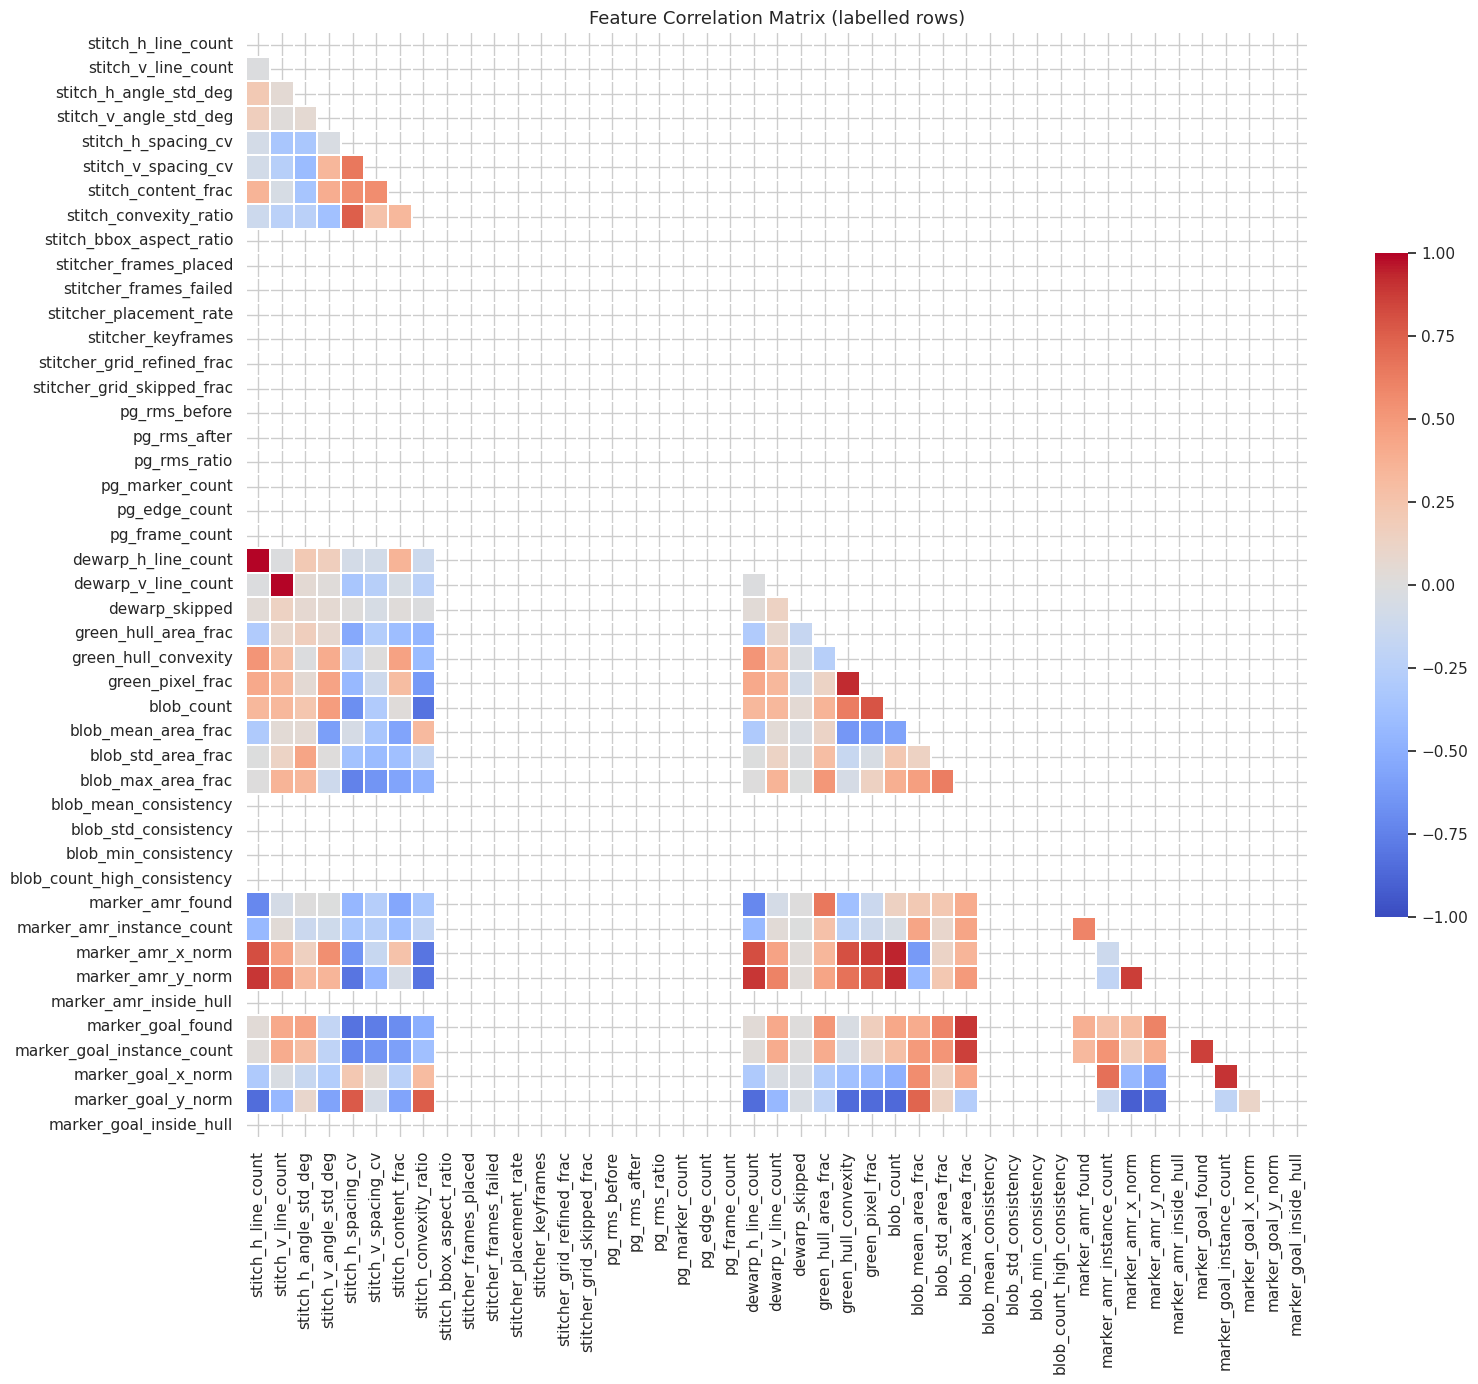

In [9]:
# Correlation heatmap of diagnostic features (use labelled rows only)
labelled = raw[raw["label"].isin(["pass", "fail"])]
feat_cols_all = [c for c in raw.columns if any(c.startswith(p)
    for p in ("stitch_","dewarp_","green_","blob_","marker_","stitcher_","pg_"))]

corr = labelled[feat_cols_all].replace(-1.0, np.nan).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.6})
ax.set_title("Feature Correlation Matrix (labelled rows)", fontsize=13)
plt.tight_layout(); plt.show()


## 2 · Feature Matrix

**What's included:** the 46 diagnostic float columns (Groups 1-6).  
**What's excluded:** `cfg_*` columns — at inference time the model is called
on live pipeline output and configuration parameters are not available.  
Rows with `diag_error=True` or `label in {unsure, unlabeled}` are excluded
from training and test sets.


In [10]:
# Define feature columns — all diagnostic groups, no config or metadata
FEATURE_COLS = sorted([c for c in raw.columns if any(c.startswith(p)
    for p in ("stitch_","dewarp_","green_","blob_","marker_","stitcher_","pg_"))])

print(f"{len(FEATURE_COLS)} feature columns:")
for c in FEATURE_COLS:
    print(f"  {c}")


45 feature columns:
  blob_count
  blob_count_high_consistency
  blob_max_area_frac
  blob_mean_area_frac
  blob_mean_consistency
  blob_min_consistency
  blob_std_area_frac
  blob_std_consistency
  dewarp_h_line_count
  dewarp_skipped
  dewarp_v_line_count
  green_hull_area_frac
  green_hull_convexity
  green_pixel_frac
  marker_amr_found
  marker_amr_inside_hull
  marker_amr_instance_count
  marker_amr_x_norm
  marker_amr_y_norm
  marker_goal_found
  marker_goal_inside_hull
  marker_goal_instance_count
  marker_goal_x_norm
  marker_goal_y_norm
  pg_edge_count
  pg_frame_count
  pg_marker_count
  pg_rms_after
  pg_rms_before
  pg_rms_ratio
  stitch_bbox_aspect_ratio
  stitch_content_frac
  stitch_convexity_ratio
  stitch_h_angle_std_deg
  stitch_h_line_count
  stitch_h_spacing_cv
  stitch_v_angle_std_deg
  stitch_v_line_count
  stitch_v_spacing_cv
  stitcher_frames_failed
  stitcher_frames_placed
  stitcher_grid_refined_frac
  stitcher_grid_skipped_frac
  stitcher_keyframes
  stitcher

In [11]:
# Filter to labelled, non-errored rows
df_train_pool = raw[
    (raw["label"].isin(["pass","fail"])) &
    (raw["diag_error"] != True)
].copy()

df_unsure = raw[raw["label"] == "unsure"].copy()

n_err = (raw["diag_error"] == True).sum()
print(f"Rows excluded (diag_error):  {n_err}")
print(f"Rows excluded (unsure):      {len(df_unsure)}")
print(f"Rows excluded (unlabeled):   {(raw['label'] == 'unlabeled').sum()}")
print(f"Rows for training/test:      {len(df_train_pool)}")
print()
vc2 = df_train_pool["label"].value_counts()
for lbl, n in vc2.items():
    print(f"  {lbl:6s}  {n:4d}  ({100*n/len(df_train_pool):.1f}%)")

X = df_train_pool[FEATURE_COLS].values
y = (df_train_pool["label"] == "pass").astype(int).values


Rows excluded (diag_error):  0
Rows excluded (unsure):      0
Rows excluded (unlabeled):   0
Rows for training/test:      670

  pass     535  (79.9%)
  fail     135  (20.1%)


## 3 · Train / Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

for split_name, ys in [("Train", y_train), ("Test", y_test)]:
    n_pos = ys.sum()
    n_neg = len(ys) - n_pos
    print(f"{split_name:6s}  total={len(ys):4d}  pass={n_pos:3d} ({100*n_pos/len(ys):.1f}%)  "
          f"fail={n_neg:3d} ({100*n_neg/len(ys):.1f}%)")

# Class imbalance ratio — needed for XGBoost
scale_pos_weight = float((y_train == 0).sum()) / max(float((y_train == 1).sum()), 1)
print(f"\nscale_pos_weight (n_fail / n_pass): {scale_pos_weight:.1f}")


Train   total= 536  pass=428 (79.9%)  fail=108 (20.1%)
Test    total= 134  pass=107 (79.9%)  fail= 27 (20.1%)

scale_pos_weight (n_fail / n_pass): 0.3


## 4 · Random Forest

`class_weight='balanced_subsample'` recomputes weights on each bootstrap
sample (better than `'balanced'` for small imbalanced data).  
Optimised for **average precision** (area under the precision-recall curve)
via 5-fold stratified cross-validation.


In [13]:
rf_space = {
    "n_estimators":      [200, 300, 500],
    "max_depth":         [None, 10, 20, 30],
    "max_features":      ["sqrt", "log2", 0.3, 0.5],
    "min_samples_leaf":  [1, 2, 5, 10],
    "min_samples_split": [2, 5, 10],
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced_subsample",
                           random_state=RANDOM_STATE, n_jobs=N_JOBS),
    rf_space,
    n_iter=RS_ITER_RF,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,          # outer loop single-threaded (estimator is already parallel)
    refit=True,
    verbose=1,
)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_

rf_cv_mean = rf_search.best_score_
rf_cv_std  = rf_search.cv_results_["std_test_score"][rf_search.best_index_]
rf_ap      = average_precision_score(y_test, rf_best.predict_proba(X_test)[:, 1])

print(f"Best params:   {rf_search.best_params_}")
print(f"CV avg prec:   {rf_cv_mean:.4f} ± {rf_cv_std:.4f}")
print(f"Test avg prec: {rf_ap:.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params:   {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
CV avg prec:   0.9938 ± 0.0090
Test avg prec: 0.9935


## 5 · XGBoost

`scale_pos_weight = n_fail / n_pass` upweights the minority class during
gradient computation.  Shallow trees (`max_depth` 2-4) regularise against
small-n overfitting.


In [14]:
xgb_space = {
    "n_estimators":     [100, 200, 400],
    "max_depth":        [2, 3, 4],
    "learning_rate":    [0.01, 0.05, 0.1],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.7, 1.0],
    "min_child_weight": [3, 5, 10],
    "gamma":            [0, 0.1, 0.5],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight,
                  random_state=RANDOM_STATE, n_jobs=N_JOBS,
                  eval_metric="aucpr", verbosity=0),
    xgb_space,
    n_iter=RS_ITER_XGB,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit=True,
    verbose=1,
)
xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_

xgb_cv_mean = xgb_search.best_score_
xgb_cv_std  = xgb_search.cv_results_["std_test_score"][xgb_search.best_index_]
xgb_ap      = average_precision_score(y_test, xgb_best.predict_proba(X_test)[:, 1])

print(f"Best params:   {xgb_search.best_params_}")
print(f"CV avg prec:   {xgb_cv_mean:.4f} ± {xgb_cv_std:.4f}")
print(f"Test avg prec: {xgb_ap:.4f}")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params:   {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 1.0}
CV avg prec:   0.9838 ± 0.0196
Test avg prec: 0.9823


## 6 · Model Comparison

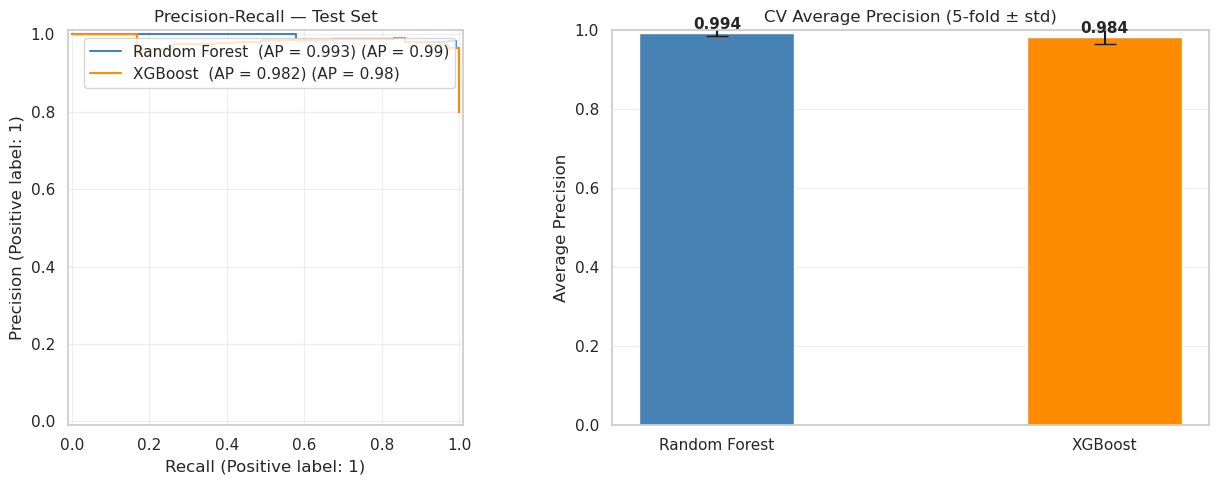

In [15]:
rf_prob  = rf_best.predict_proba(X_test)[:, 1]
xgb_prob = xgb_best.predict_proba(X_test)[:, 1]

# ── Precision-recall curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for name, prob, color in [("Random Forest", rf_prob, "steelblue"),
                            ("XGBoost",      xgb_prob, "darkorange")]:
    ap = average_precision_score(y_test, prob)
    PrecisionRecallDisplay.from_predictions(y_test, prob, ax=ax,
        name=f"{name}  (AP = {ap:.3f})", color=color)
ax.set_title("Precision-Recall — Test Set")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# ── CV summary bars ───────────────────────────────────────────────────────────
ax2 = axes[1]
models = ["Random Forest", "XGBoost"]
means  = [rf_cv_mean, xgb_cv_mean]
stds   = [rf_cv_std,  xgb_cv_std]
colors = ["steelblue", "darkorange"]
bars = ax2.bar(models, means, yerr=stds, capsize=8, color=colors,
               edgecolor="white", width=0.4)
for bar, m in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, m + 0.01, f"{m:.3f}",
             ha="center", fontsize=11, fontweight="bold")
ax2.set_ylim(0, 1)
ax2.set_title(f"CV Average Precision ({CV_FOLDS}-fold ± std)")
ax2.set_ylabel("Average Precision")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()


In [16]:
# ── Metrics table at default 0.5 threshold ────────────────────────────────────
rows = []
for name, prob, model in [("Random Forest", rf_prob, rf_best),
                            ("XGBoost",      xgb_prob, xgb_best)]:
    pred = (prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0,1]).ravel() \
                     if confusion_matrix(y_test, pred).size == 4 else (0,0,0,0)
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    rec  = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
    ap   = average_precision_score(y_test, prob)
    rows.append({"Model": name, "Precision(pass)": f"{prec:.3f}",
                 "Recall(pass)": f"{rec:.3f}", "F1(pass)": f"{f1:.3f}",
                 "Avg Precision": f"{ap:.3f}", "TP": tp, "FP": fp, "FN": fn})

print("Metrics at threshold = 0.50 (default):")
display(pd.DataFrame(rows).set_index("Model"))
print("\nNote: threshold will be tuned in Section 7.")


Metrics at threshold = 0.50 (default):


,Precision(pass),Recall(pass),F1(pass),Avg Precision,TP,FP,FN
Model,,,,,,,
Random Forest,0.964,1.000,0.982,0.993,107,4,0
XGBoost,0.964,1.000,0.982,0.982,107,4,0



Note: threshold will be tuned in Section 7.


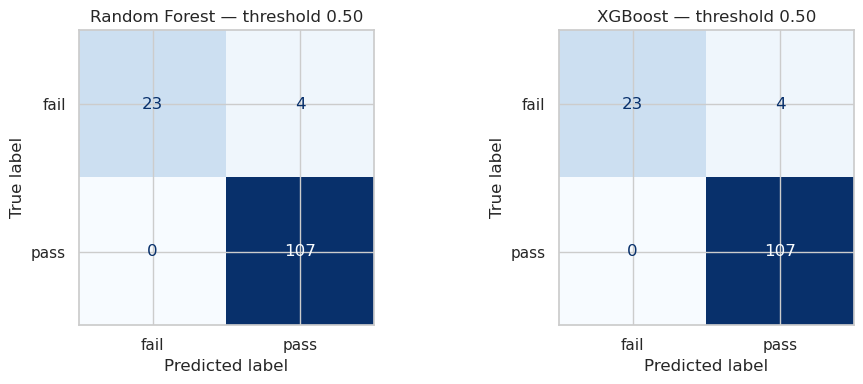

In [17]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name, prob in zip(axes,
                           ["Random Forest", "XGBoost"],
                           [rf_prob, xgb_prob]):
    pred = (prob >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=["fail", "pass"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name} — threshold 0.50")
plt.tight_layout(); plt.show()


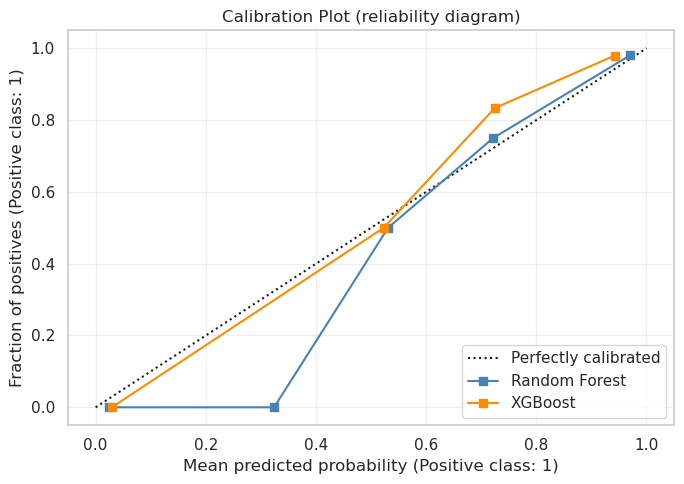

A well-calibrated model follows the diagonal.
If curves deviate significantly, consider isotonic regression calibration.


In [18]:
# ── Calibration curves ────────────────────────────────────────────────────────
# Shows whether predicted probabilities match actual frequencies.
# With small imbalanced data, raw probabilities are often poorly calibrated.
fig, ax = plt.subplots(figsize=(7, 5))
for name, prob, color in [("Random Forest", rf_prob, "steelblue"),
                            ("XGBoost",      xgb_prob, "darkorange")]:
    CalibrationDisplay.from_predictions(y_test, prob, n_bins=5, ax=ax,
        name=name, color=color)
ax.set_title("Calibration Plot (reliability diagram)")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("A well-calibrated model follows the diagonal.")
print("If curves deviate significantly, consider isotonic regression calibration.")


## 7 · Threshold Selection

The default 0.5 threshold is almost certainly wrong here.
Because **false positives are more costly** (accepting a bad map),
we predict "pass" only when the model is highly confident.

The cell below selects the **lowest threshold** at which precision on
the "pass" class reaches `TARGET_PRECISION`.  Adjust `TARGET_PRECISION`
in the config cell and re-run if needed.


In [19]:
# Pick the better model by test-set average precision
if xgb_ap >= rf_ap:
    chosen_name, chosen_model, chosen_prob = "XGBoost", xgb_best, xgb_prob
else:
    chosen_name, chosen_model, chosen_prob = "Random Forest", rf_best, rf_prob

print(f"Chosen model: {chosen_name}  (AP = {max(rf_ap, xgb_ap):.4f})")


Chosen model: Random Forest  (AP = 0.9935)


In [20]:
precisions, recalls, thresholds = precision_recall_curve(y_test, chosen_prob)
# precisions/recalls have one extra element — trim to match thresholds
prec_t = precisions[:-1]
rec_t  = recalls[:-1]

valid = np.where(prec_t >= TARGET_PRECISION)[0]

if len(valid) == 0:
    print(f"WARNING: model never reaches {TARGET_PRECISION:.0%} precision on the test set.")
    print("Options:")
    print(f"  1. Lower TARGET_PRECISION (currently {TARGET_PRECISION})")
    print("  2. Collect more labelled data — test set may be too small to be reliable")
    print("  3. Review the feature engineering — some features may be misleading")
    chosen_threshold = 0.5
    op_prec = op_rec = None
else:
    # Pick the LOWEST threshold that satisfies the precision constraint
    # (highest recall while maintaining required precision)
    idx = valid[0]
    chosen_threshold = float(thresholds[idx])
    op_prec = float(prec_t[idx])
    op_rec  = float(rec_t[idx])
    n_tp = int(op_rec * y_test.sum())
    print(f"TARGET_PRECISION:   {TARGET_PRECISION:.0%}")
    print(f"Chosen threshold:   {chosen_threshold:.4f}")
    print(f"Precision @ thr:    {op_prec:.3f}")
    print(f"Recall    @ thr:    {op_rec:.3f}  ({n_tp}/{int(y_test.sum())} true passes caught)")
    print()
    n_fp = int(((chosen_prob >= chosen_threshold) & (y_test == 0)).sum())
    print(f"False positives on test set: {n_fp}  (bad maps accepted as good)")


TARGET_PRECISION:   90%
Chosen threshold:   0.0711
Precision @ thr:    0.907
Recall    @ thr:    1.000  (107/107 true passes caught)

False positives on test set: 11  (bad maps accepted as good)


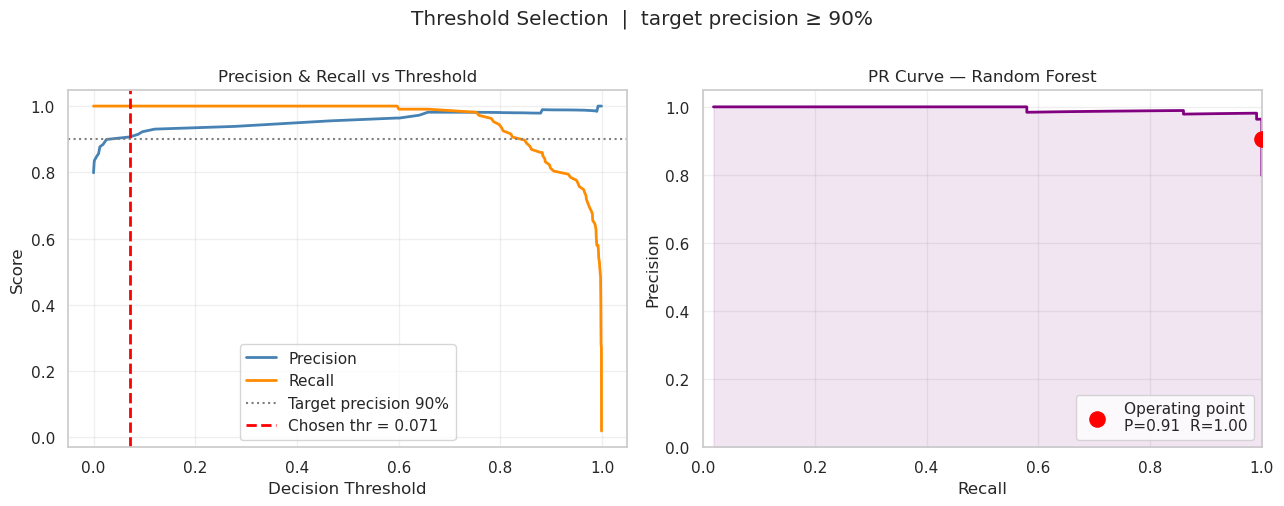

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: precision & recall vs threshold
ax1.plot(thresholds, prec_t, label="Precision", color="steelblue", lw=2)
ax1.plot(thresholds, rec_t,  label="Recall",    color="darkorange", lw=2)
ax1.axhline(TARGET_PRECISION, color="gray", linestyle=":", lw=1.5,
            label=f"Target precision {TARGET_PRECISION:.0%}")
if op_prec is not None:
    ax1.axvline(chosen_threshold, color="red", linestyle="--", lw=2,
                label=f"Chosen thr = {chosen_threshold:.3f}")
ax1.set_xlabel("Decision Threshold"); ax1.set_ylabel("Score")
ax1.set_title("Precision & Recall vs Threshold")
ax1.legend(); ax1.grid(True, alpha=0.3)

# Right: PR curve with operating point
ax2.plot(rec_t, prec_t, color="purple", lw=2)
ax2.fill_between(rec_t, prec_t, alpha=0.1, color="purple")
if op_prec is not None:
    ax2.scatter([op_rec], [op_prec], color="red", zorder=6, s=120,
                label=f"Operating point\nP={op_prec:.2f}  R={op_rec:.2f}")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title(f"PR Curve — {chosen_name}")
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1.05)

plt.suptitle(f"Threshold Selection  |  target precision ≥ {TARGET_PRECISION:.0%}", y=1.01)
plt.tight_layout(); plt.show()


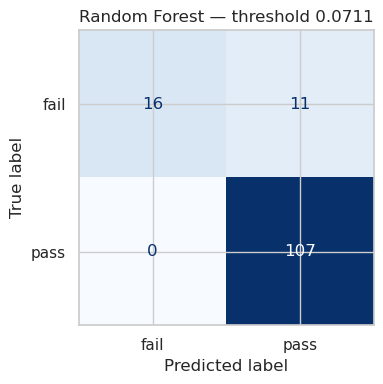

In [22]:
# Final confusion matrix at the chosen threshold
pred_final = (chosen_prob >= chosen_threshold).astype(int)
cm = confusion_matrix(y_test, pred_final, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=["fail", "pass"]).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"{chosen_name} — threshold {chosen_threshold:.4f}")
plt.tight_layout(); plt.show()


In [23]:
# Predictions on unsure rows (informative — not used for training)
if len(df_unsure) > 0:
    Xu = df_unsure[FEATURE_COLS].values
    pu = chosen_model.predict_proba(Xu)[:, 1]
    df_unsure = df_unsure.copy()
    df_unsure["p_pass"]   = pu
    df_unsure["predicted"] = np.where(pu >= chosen_threshold, "pass", "fail")
    print(f"Predictions for {len(df_unsure)} 'unsure' rows (not used in training):")
    display(df_unsure[["sweep","run_id","p_pass","predicted"]]
            .sort_values("p_pass", ascending=False)
            .reset_index(drop=True))
else:
    print("No 'unsure' rows in the dataset.")


No 'unsure' rows in the dataset.


## 8 · Feature Importance & SHAP

Understanding *which* features drive the model helps:
- Verify the model has learned sensible patterns (not spurious correlations)
- Identify which diagnostics to focus on if map quality is poor
- Guide future feature engineering for the XGBoost classifier


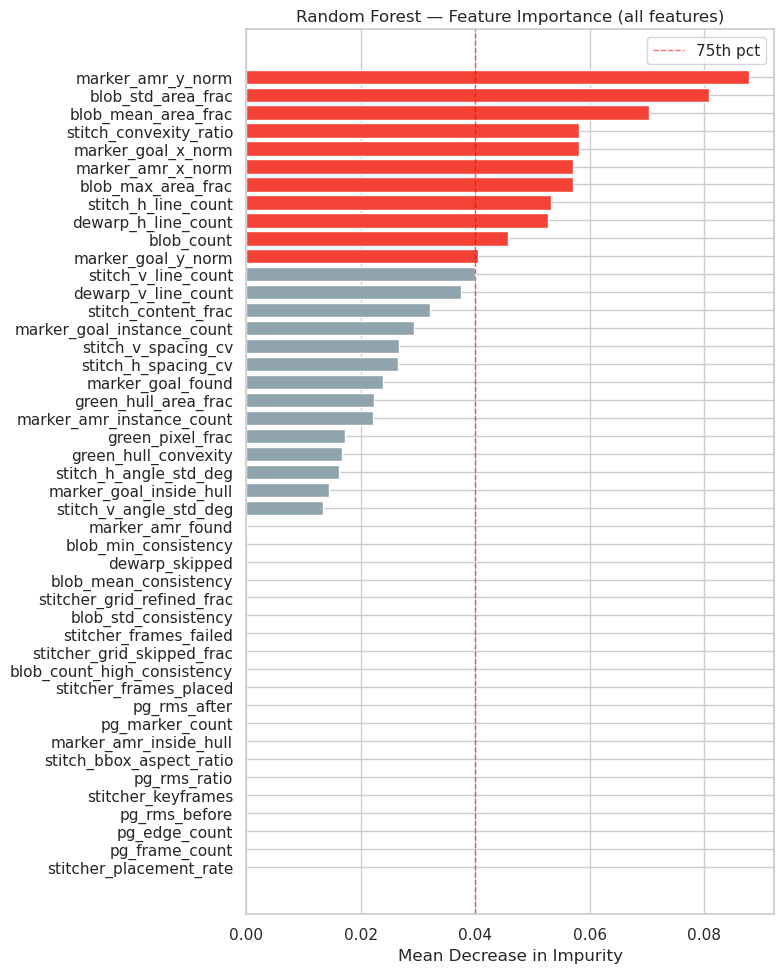

In [24]:
# ── Random Forest — built-in impurity importance ──────────────────────────────
rf_imp = pd.Series(rf_best.feature_importances_, index=FEATURE_COLS) \
           .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(6, len(FEATURE_COLS) * 0.22)))
colors_imp = ["#f44336" if rf_imp.iloc[i] > rf_imp.quantile(0.75) else "#90a4ae"
              for i in range(len(rf_imp))]
ax.barh(rf_imp.index, rf_imp.values, color=colors_imp, edgecolor="white")
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Random Forest — Feature Importance (all features)")
ax.axvline(rf_imp.quantile(0.75), color="red", linestyle="--", lw=1,
           alpha=0.6, label="75th pct")
ax.legend()
plt.tight_layout(); plt.show()


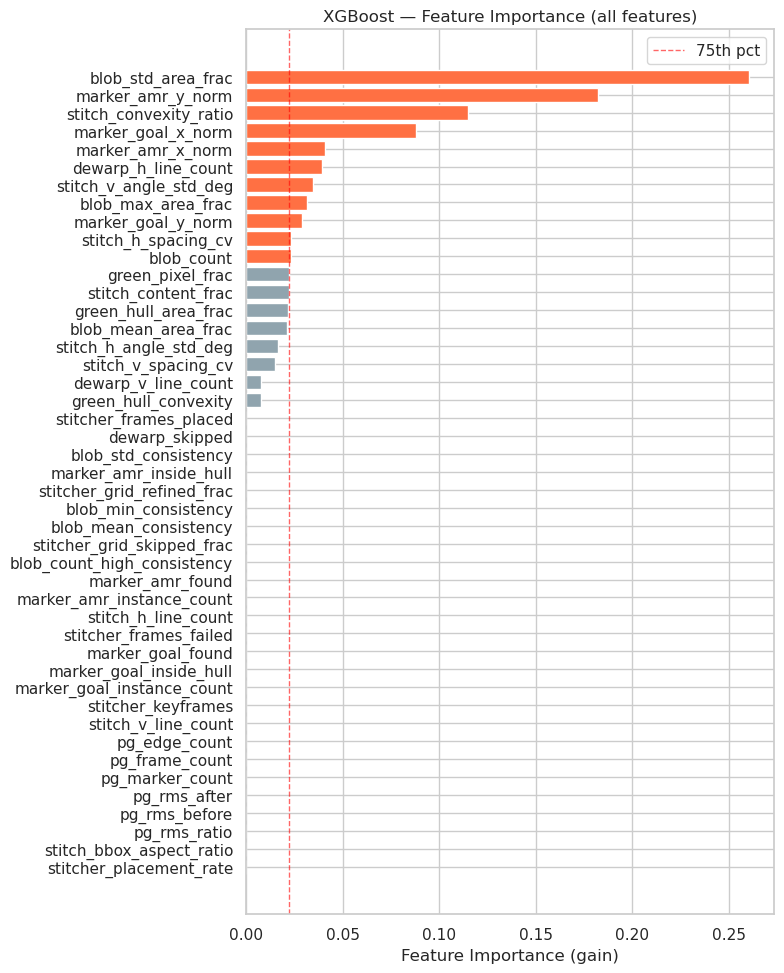

In [25]:
# ── XGBoost — built-in gain importance ───────────────────────────────────────
xgb_imp = pd.Series(xgb_best.feature_importances_, index=FEATURE_COLS) \
            .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(6, len(FEATURE_COLS) * 0.22)))
colors_xgb = ["#ff7043" if xgb_imp.iloc[i] > xgb_imp.quantile(0.75) else "#90a4ae"
               for i in range(len(xgb_imp))]
ax.barh(xgb_imp.index, xgb_imp.values, color=colors_xgb, edgecolor="white")
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("XGBoost — Feature Importance (all features)")
ax.axvline(xgb_imp.quantile(0.75), color="red", linestyle="--", lw=1,
           alpha=0.6, label="75th pct")
ax.legend()
plt.tight_layout(); plt.show()


PermutationExplainer explainer: 135it [00:25,  3.70it/s]                         


SHAP summary plot — direction and magnitude of each feature's effect


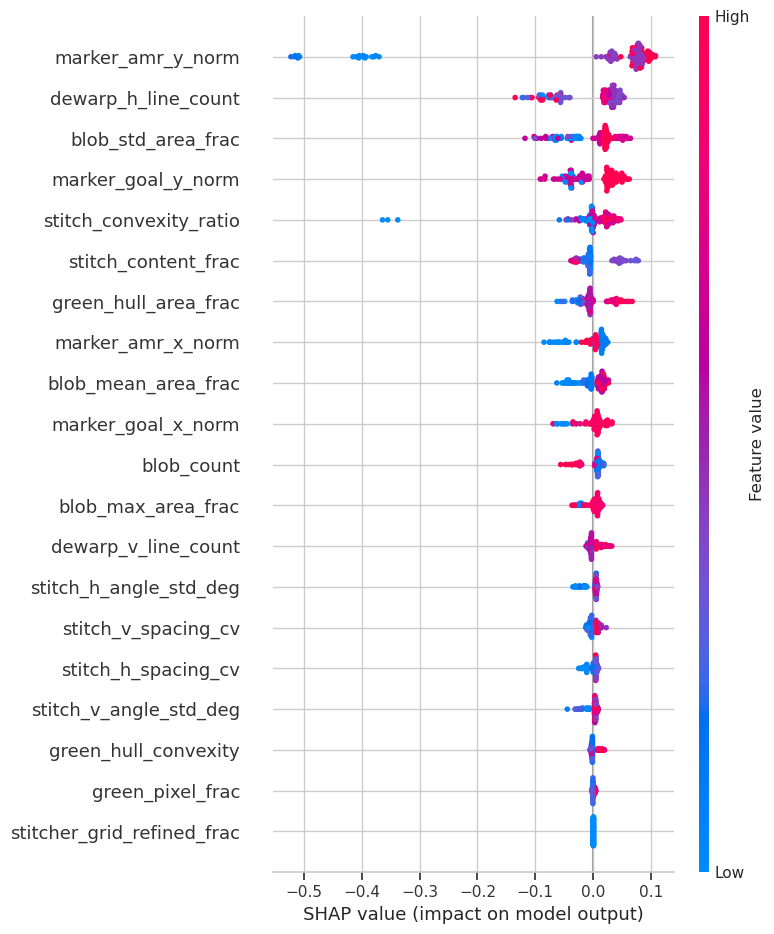

In [26]:
# ── SHAP — XGBoost (full analysis) ───────────────────────────────────────────
# shap.TreeExplainer is incompatible with XGBoost 3.x (base_score format changed).
# Use shap.Explainer with a predict callable instead.
if not _SHAP:
    print("SHAP not installed — skipping. pip install shap")
else:
    _predict_pos = lambda x: xgb_best.predict_proba(x)[:, 1]
    explainer = shap.Explainer(
        _predict_pos,
        shap.maskers.Independent(X_test, max_samples=len(X_test)),
    )
    shap_vals = explainer(X_test)   # Explanation object; .values shape (n_test, n_features)

    print("SHAP summary plot — direction and magnitude of each feature's effect")
    shap.summary_plot(shap_vals.values, X_test, feature_names=FEATURE_COLS, show=True)


SHAP bar plot — mean absolute impact (comparable to feature importance)


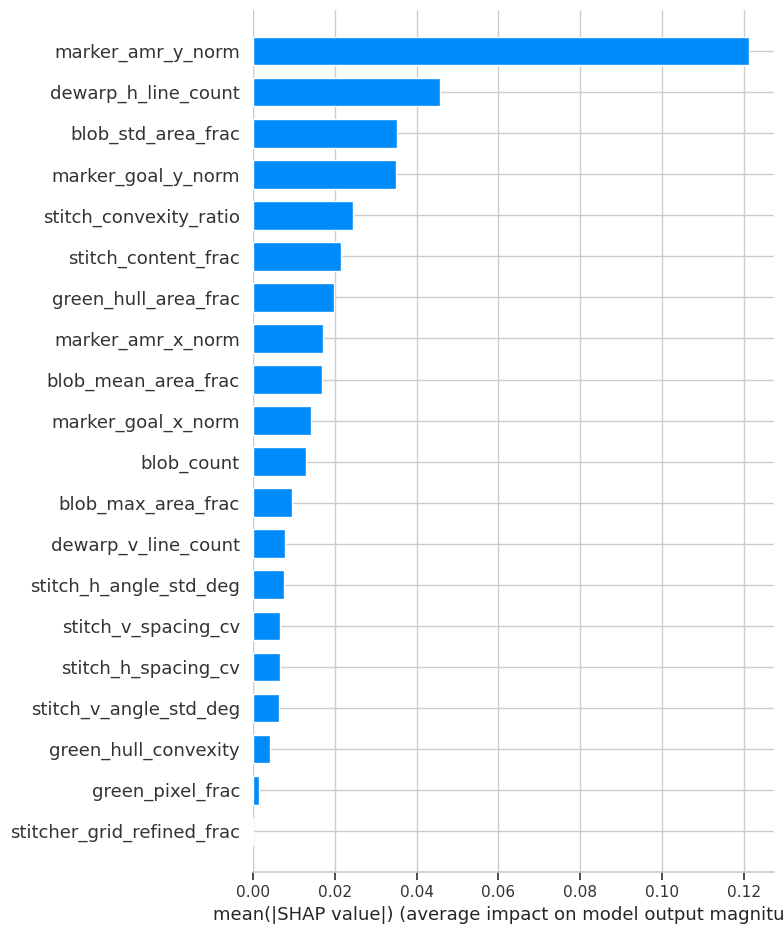

In [27]:
if _SHAP:
    print("SHAP bar plot — mean absolute impact (comparable to feature importance)")
    shap.summary_plot(shap_vals.values, X_test, feature_names=FEATURE_COLS,
                      plot_type="bar", show=True)


False positives on test set: 11
SHAP waterfall plots for each false positive:
(These show which features pushed the model toward 'pass' incorrectly)



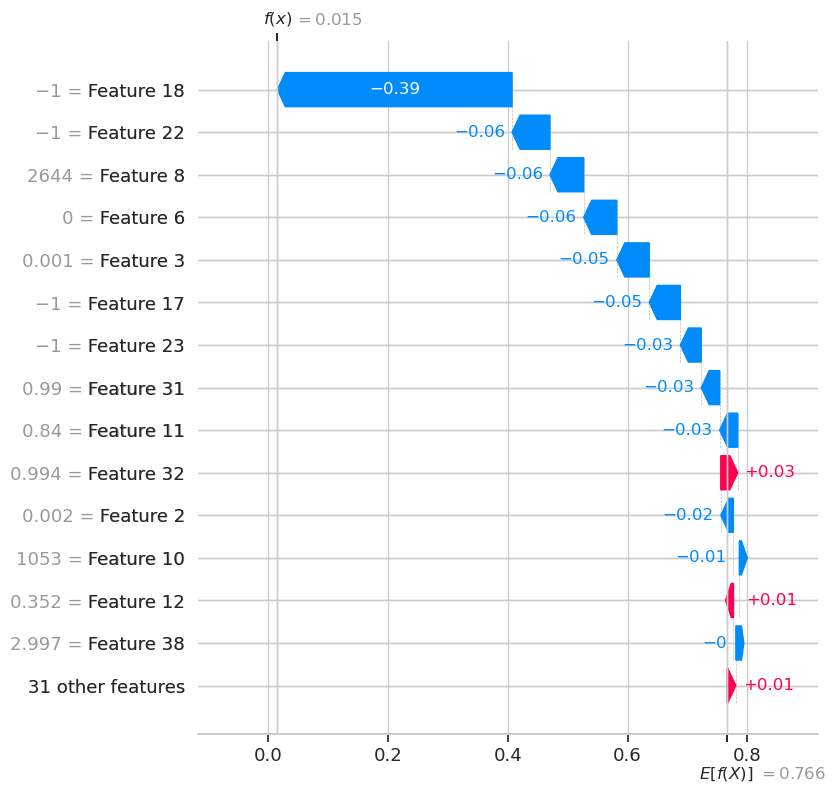

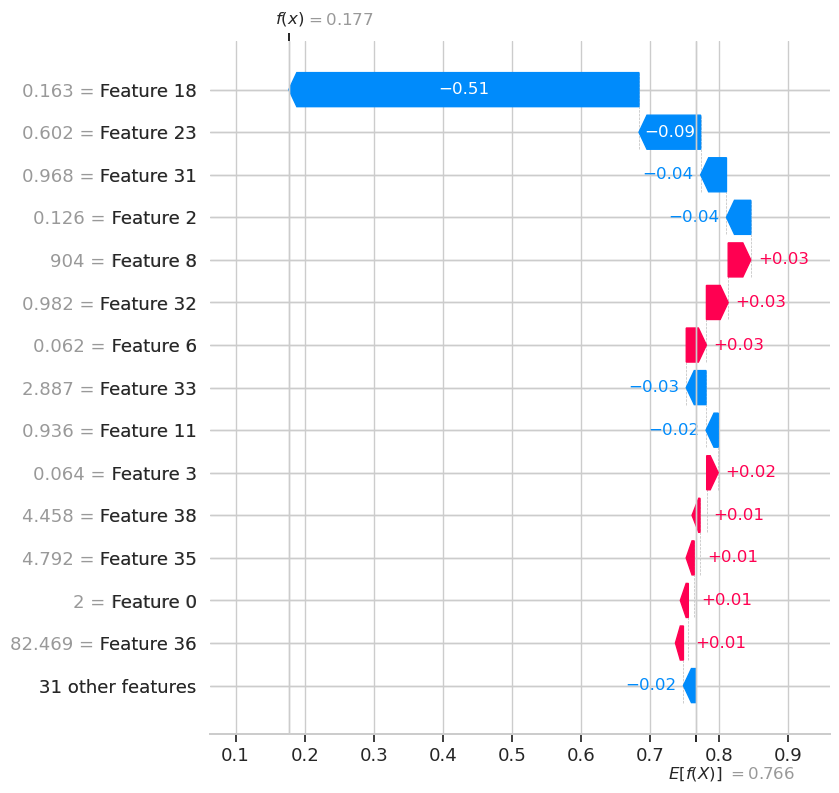

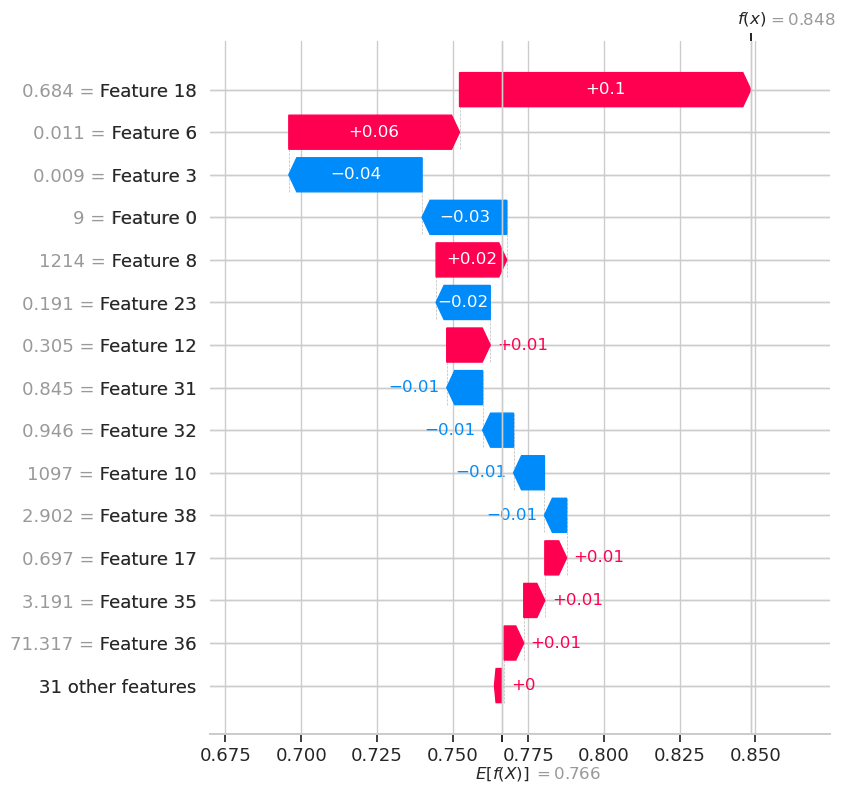

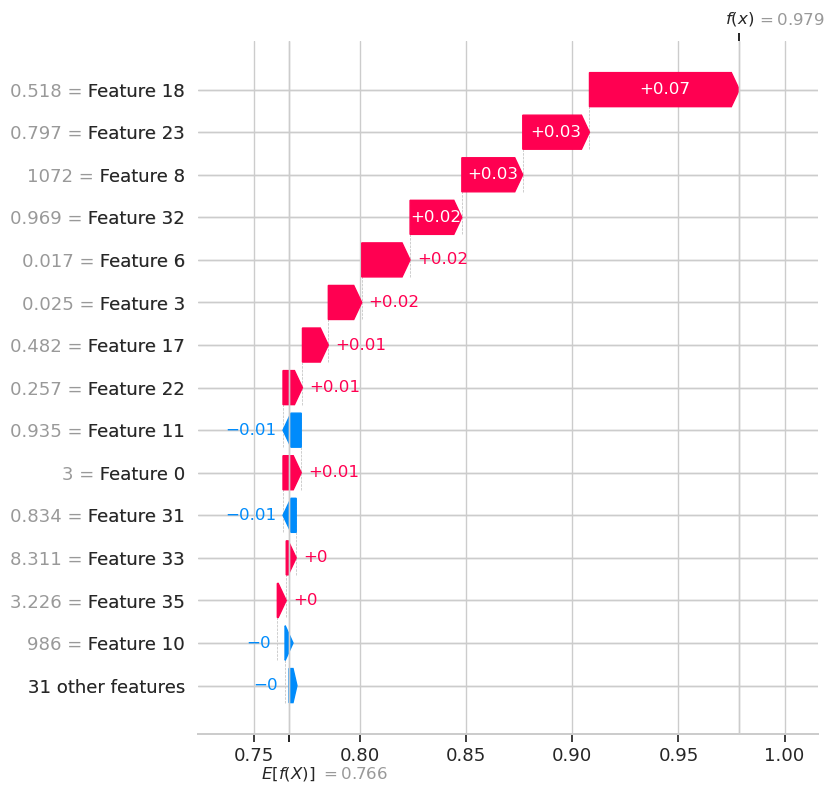

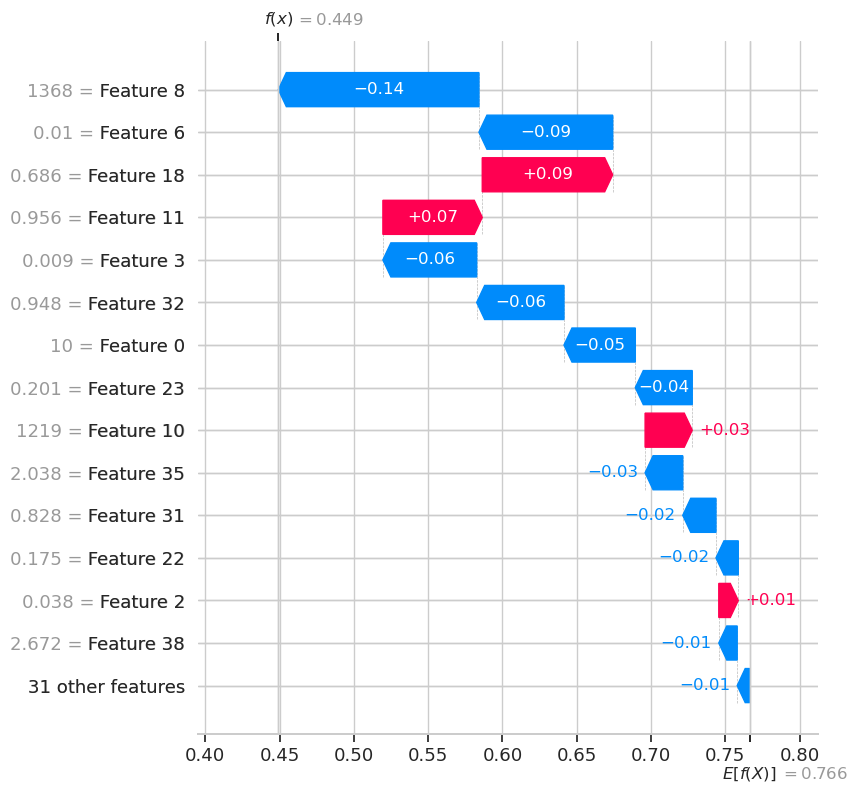

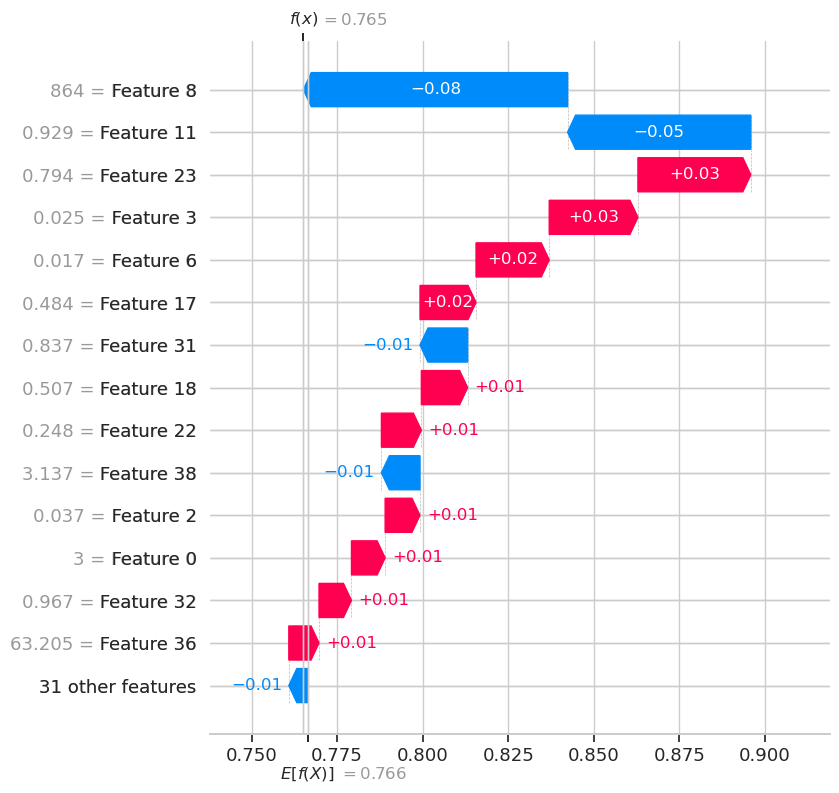

In [28]:
if _SHAP:
    # False-positive analysis — SHAP waterfall for each FP in the test set
    fp_idx = np.where((chosen_prob >= chosen_threshold) & (y_test == 0))[0]
    print(f"False positives on test set: {len(fp_idx)}")
    if len(fp_idx) == 0:
        print("No false positives at the chosen threshold — nothing to analyse.")
    else:
        print("SHAP waterfall plots for each false positive:")
        print("(These show which features pushed the model toward 'pass' incorrectly)\n")
        for fp in fp_idx[:6]:   # cap at 6 to avoid huge output
            shap.plots.waterfall(shap_vals[fp], max_display=15, show=True)


## 9 · Save Model

Each training run creates a new versioned directory `models/v{N}/`.  
`models/latest` is a symlink to the most recent version.

The saved files:
- `model.joblib` — the fitted estimator (RF or XGBoost)
- `feature_names.json` — ordered feature column list (required at inference)
- `threshold.json` — chosen threshold + full training metadata


In [29]:
MODEL_DIR.mkdir(exist_ok=True)

# Auto-increment version number
existing_v = sorted(
    [d for d in MODEL_DIR.iterdir() if d.is_dir() and d.name.startswith("v")
     and d.name[1:].isdigit()],
    key=lambda d: int(d.name[1:])
)
version_num = len(existing_v) + 1
version_dir = MODEL_DIR / f"v{version_num}"
version_dir.mkdir()

# Save model
joblib.dump(chosen_model, version_dir / "model.joblib")

# Save ordered feature list (inference must use the same order)
with open(version_dir / "feature_names.json", "w") as f:
    json.dump(FEATURE_COLS, f, indent=2)

# Save metadata
n_pass_tr = int((y_train == 1).sum())
n_fail_tr = int((y_train == 0).sum())
metadata = {
    "model_type":              chosen_name,
    "version":                 version_num,
    "threshold":               chosen_threshold,
    "precision_at_threshold":  op_prec,
    "recall_at_threshold":     op_rec,
    "rf_average_precision":    float(rf_ap),
    "xgb_average_precision":   float(xgb_ap),
    "chosen_model_ap":         float(max(rf_ap, xgb_ap)),
    "rf_cv_mean":              float(rf_cv_mean),
    "rf_cv_std":               float(rf_cv_std),
    "xgb_cv_mean":             float(xgb_cv_mean),
    "xgb_cv_std":              float(xgb_cv_std),
    "n_train":                 int(len(y_train)),
    "n_test":                  int(len(y_test)),
    "n_pass_train":            n_pass_tr,
    "n_fail_train":            n_fail_tr,
    "feature_count":           len(FEATURE_COLS),
    "target_precision":        TARGET_PRECISION,
    "trained_on":              [str(p) for p in FEATURE_CSVS],
    "trained_date":            str(date.today()),
    "rf_best_params":          rf_search.best_params_,
    "xgb_best_params":         xgb_search.best_params_,
}
with open(version_dir / "threshold.json", "w") as f:
    json.dump(metadata, f, indent=2)

# Update latest symlink
latest = MODEL_DIR / "latest"
if latest.exists() or latest.is_symlink():
    latest.unlink()
latest.symlink_to(version_dir.name)

print(f"Saved → {version_dir}/")
print(f"Symlink: models/latest → {version_dir.name}")
print(f"\nFull metadata:")
for k, v in metadata.items():
    print(f"  {k}: {v}")


Saved → models/v1/
Symlink: models/latest → v1

Full metadata:
  model_type: Random Forest
  version: 1
  threshold: 0.07109419315165648
  precision_at_threshold: 0.9067796610169492
  recall_at_threshold: 1.0
  rf_average_precision: 0.9934671958953629
  xgb_average_precision: 0.9822880999518148
  chosen_model_ap: 0.9934671958953629
  rf_cv_mean: 0.9937963426252219
  rf_cv_std: 0.00895875917477345
  xgb_cv_mean: 0.9838183586565039
  xgb_cv_std: 0.01960283180144239
  n_train: 536
  n_test: 134
  n_pass_train: 428
  n_fail_train: 108
  feature_count: 45
  target_precision: 0.9
  trained_on: ['18-21/features.csv']
  trained_date: 2026-06-09
  rf_best_params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
  xgb_best_params: {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 1.0}


### Inference snippet

Copy this into your ROS node or evaluation script:

```python
import joblib, json
import numpy as np
from map_diagnostics import compute_diagnostics, DiagnosticsConfig

_model    = joblib.load("models/latest/model.joblib")
_meta     = json.load(open("models/latest/threshold.json"))
_features = json.load(open("models/latest/feature_names.json"))
_threshold = _meta["threshold"]

def predict_map_quality(transfer_stages, transfer_cfg, stitched_map=None):
    """Returns (accept: bool, confidence: float)."""
    diag = compute_diagnostics(transfer_stages, transfer_cfg,
                               stitched_map=stitched_map)
    fv   = diag.to_feature_vector()
    x    = np.array([[fv[k] for k in _features]])
    prob = float(_model.predict_proba(x)[0, 1])
    return prob >= _threshold, prob
```


## 10 · Retraining & Version Comparison

**To retrain with new sweep data:**
1. Add the new `features.csv` path to `FEATURE_CSVS` in Section 0
2. Re-run all cells from top to bottom
3. The save cell auto-increments the version number
4. The comparison table below shows all versions side by side


In [30]:
all_v = sorted(
    [d for d in MODEL_DIR.iterdir() if d.is_dir() and d.name.startswith("v")
     and d.name[1:].isdigit()],
    key=lambda d: int(d.name[1:])
)

if len(all_v) < 2:
    print("Only one version exists. Train again with new data to see the comparison.")
else:
    rows = []
    for vd in all_v:
        mp = vd / "threshold.json"
        if not mp.exists():
            continue
        m = json.load(open(mp))
        rows.append({
            "Version":         vd.name,
            "Model":           m.get("model_type", "?"),
            "AP (test)":       f"{m.get('chosen_model_ap', 0):.3f}",
            "RF CV":           f"{m.get('rf_cv_mean',0):.3f} ± {m.get('rf_cv_std',0):.3f}",
            "XGB CV":          f"{m.get('xgb_cv_mean',0):.3f} ± {m.get('xgb_cv_std',0):.3f}",
            "Prec @ thr":      f"{m['precision_at_threshold']:.3f}" if m.get("precision_at_threshold") else "—",
            "Recall @ thr":    f"{m['recall_at_threshold']:.3f}"    if m.get("recall_at_threshold")    else "—",
            "Threshold":       f"{m.get('threshold', 0.5):.4f}",
            "n_train":         m.get("n_train", 0),
            "n_pass":          m.get("n_pass_train", 0),
            "Date":            m.get("trained_date", "?"),
        })
    cmp = pd.DataFrame(rows).set_index("Version")
    display(cmp)
    print()
    # Highlight improvement on the chosen metric
    if len(rows) >= 2:
        prev_ap = float(rows[-2]["AP (test)"])
        curr_ap = float(rows[-1]["AP (test)"])
        delta   = curr_ap - prev_ap
        sign    = "+" if delta >= 0 else ""
        print(f"Average precision: {prev_ap:.3f} → {curr_ap:.3f}  ({sign}{delta:.3f})")
        if delta > 0:
            print("  ↑ Improvement — update models/latest symlink? (re-run save cell)")
        else:
            print("  ↓ No improvement — previous version may still be preferable.")
            print("    Check: was the new data significantly different?")
            print("    The previous model is still at models/v{} and can be used directly.".format(
                all_v[-2].name))


Only one version exists. Train again with new data to see the comparison.
